### Imports

In [ ]:
# Standard library imports
import os
import re
import time
import collections
import shutil

# Third-party numerical/scientific imports
import numpy as np
import cv2

# Visualization imports
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

# Image processing imports
import PIL
import skimage.io as io
from PIL import Image, ImageFont, ImageDraw, ImageEnhance

# TensorFlow/Keras imports - UPDATED FOR TF 2.x
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend, optimizers, utils
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras.applications import VGG19
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard, EarlyStopping, ReduceLROnPlateau

# Utility imports
import glob  # to count jpg files

### Retraining

In [ ]:
modelPath = r"E:\\Meenal-TIL_seg(300GB)\\3ClassesVGG19TuneAugmentation_old.hdf5"

def constructVGGModel(modelPath):
    dx=dy=48
    # modelPath = r'C:\Users\mrl\Desktop\TILseg_Project\3ClassesVGG19TuneAugmentation.hdf5'
    res_conv = VGG19(weights='imagenet', include_top=False, input_shape=(dx, dy, 3))
    # Freeze the layers except the last 12 layers
    for layer in res_conv.layers[:-12]:
        layer.trainable = False
    # Create the model
    global model1
    model1 = Sequential()
    # Add the res convolutional base model
    model1.add(res_conv)
    # Add new layers
    model1.add(Flatten())
    model1.add(Dense(1024, activation='relu'))
    model1.add(Dropout(0.2))
    model1.add(Dense(3, activation='softmax'))
    model1.load_weights(modelPath)
    return model1


# Print the model summary before making any changes
print("Original model summary:")
model = constructVGGModel(modelPath)
model.summary()

# Freeze all layers except the last few layers
# Adjust the slicing based on which layers you want to fine-tune
for layer in model.layers[:-4]:
    layer.trainable = False

# Print the model summary after freezing layers
print("Model summary after freezing layers:")
model.summary()

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the final model summary to confirm the changes
print("Final model summary:")
model.summary()

Original model summary:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 1, 1, 512)         20024384  
                                                                 
 flatten (Flatten)           (None, 512)               0         
                                                                 
 dense (Dense)               (None, 1024)              525312    
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_1 (Dense)             (None, 3)                 3075      
                                                                 
Total params: 20,552,771
Trainable params: 18,817,283
Non-trainable params: 1,735,488
_________________________________________________________________
Model summar

In [ ]:
# Define paths
data_dir = r"E:\\TILseg2\\3CC_retraining\\3CC_retraining_V\\retraining"
train_dir = r"E:\\TILseg2\\3CC_retraining\\3CC_retraining_V\\data_split_V_part3\\train"
val_dir = r"E:\\TILseg2\\3CC_retraining\\3CC_retraining_V\\data_split_V_part3\\val"
test_dir = r"E:\\TILseg2\\3CC_retraining\\3CC_retraining_V\\data_split_V_part3\\test"

In [ ]:
# Create directories for train, validation, and test sets
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Function to split data
def split_data(class_name, source_dir, train_dir, val_dir, test_dir, val_split=0.2, test_split=0.1):
    class_dir = os.path.join(source_dir, class_name)
    images = os.listdir(class_dir)
    train_images, val_images = train_test_split(images, test_size=val_split)
    train_images, test_images = train_test_split(train_images, test_size=test_split / (1 - val_split))

    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

    for image in train_images:
        shutil.copy(os.path.join(class_dir, image), os.path.join(train_dir, class_name, image))
    
    for image in val_images:
        shutil.copy(os.path.join(class_dir, image), os.path.join(val_dir, class_name, image))

    for image in test_images:
        shutil.copy(os.path.join(class_dir, image), os.path.join(test_dir, class_name, image))

# Split the data for each class
for class_name in os.listdir(data_dir):
    split_data(class_name, data_dir, train_dir, val_dir, test_dir)

In [ ]:
# Create an ImageDataGenerator for the training data with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,             # Rotating the image (old:20)
    shear_range=0.2,               # Shearing
    zoom_range=0.2,                # Zooming in/out
    horizontal_flip=True,          # Horizontal flipping
    vertical_flip=True,            # Vertical flipping
    brightness_range=[0.8, 1.2],   # Brightness jitter (new)
    width_shift_range=0.2,         # Shifting horizontally
    height_shift_range=0.2         # Shifting vertically
)

# Create an ImageDataGenerator for the validation and test data (only rescaling)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create the train generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),    # Resize images to 48x48 pixels
    batch_size=32,
    class_mode='categorical'
)

# Create the validation generator
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(48, 48),    # Resize images to 48x48 pixels
    batch_size=32,
    class_mode='categorical'
)

# Create the test generator
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),    # Resize images to 48x48 pixels
    batch_size=32,
    class_mode='categorical',
    shuffle=False            # Important for evaluation and predictions
)

# Print the class indices to ensure they match your expected class_to_idx mapping
print(train_generator.class_indices)
print(val_generator.class_indices)
print(test_generator.class_indices)

Found 25023 images belonging to 3 classes.
Found 7151 images belonging to 3 classes.
Found 3576 images belonging to 3 classes.
{'epithelium': 0, 'others': 1, 'stroma': 2}
{'epithelium': 0, 'others': 1, 'stroma': 2}
{'epithelium': 0, 'others': 1, 'stroma': 2}


Epoch 1/50
782/782 [==============================] - ETA: 0s - loss: 0.4442 - accuracy: 0.8234
Epoch 1: val_accuracy improved from -inf to 0.86827, saving model to model_retraining_V_part3_20250123.h5
782/782 [==============================] - 158s 201ms/step - loss: 0.4442 - accuracy: 0.8234 - val_loss: 0.3412 - val_accuracy: 0.8683 - lr: 0.0010
Epoch 2/50
781/782 [============================>.] - ETA: 0s - loss: 0.3855 - accuracy: 0.8430
Epoch 2: val_accuracy did not improve from 0.86827
782/782 [==============================] - 27s 34ms/step - loss: 0.3856 - accuracy: 0.8430 - val_loss: 0.3409 - val_accuracy: 0.8660 - lr: 0.0010
Epoch 3/50
781/782 [============================>.] - ETA: 0s - loss: 0.3600 - accuracy: 0.8565
Epoch 3: val_accuracy did not improve from 0.86827
782/782 [==============================] - 27s 34ms/step - loss: 0.3602 - accuracy: 0.8564 - val_loss: 0.3569 - val_accuracy: 0.8546 - lr: 0.0010
Epoch 4/50
781/782 [============================>.] - ETA: 0s - 

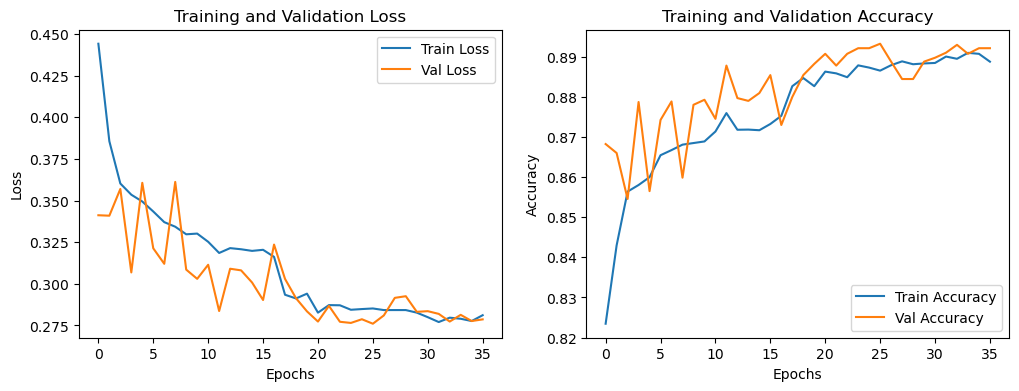

In [ ]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, verbose=1, restore_best_weights=True),
    ModelCheckpoint('model_retraining_V_part3_20250123.h5', monitor='val_accuracy', save_best_only=True, verbose=1), # TODO change model name
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=5, verbose=1)
]

# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,  # Start with a baseline number of epochs
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator),
    callbacks=callbacks
)

# Plot training and validation curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()


Epoch 1/50
781/782 [============================>.] - ETA: 0s - loss: 0.2832 - accuracy: 0.8873
Epoch 1: val_accuracy did not improve from 0.89330
782/782 [==============================] - 27s 35ms/step - loss: 0.2831 - accuracy: 0.8873 - val_loss: 0.2770 - val_accuracy: 0.8926 - lr: 1.0000e-06
Epoch 2/50
781/782 [============================>.] - ETA: 0s - loss: 0.2782 - accuracy: 0.8889
Epoch 2: val_accuracy did not improve from 0.89330
782/782 [==============================] - 27s 35ms/step - loss: 0.2784 - accuracy: 0.8888 - val_loss: 0.2780 - val_accuracy: 0.8920 - lr: 1.0000e-06
Epoch 3/50
781/782 [============================>.] - ETA: 0s - loss: 0.2830 - accuracy: 0.8892
Epoch 3: val_accuracy did not improve from 0.89330
782/782 [==============================] - 28s 35ms/step - loss: 0.2831 - accuracy: 0.8892 - val_loss: 0.2781 - val_accuracy: 0.8919 - lr: 1.0000e-06
Epoch 4/50
781/782 [============================>.] - ETA: 0s - loss: 0.2820 - accuracy: 0.8879
Epoch 4: val_

C:\Users\Waluigi\AppData\Local\Temp\ipykernel_21168\2909471672.py:12: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  evaluation = model.evaluate_generator(test_generator)


Test Loss: 0.2850193679332733
Test Accuracy: 0.8940156698226929


C:\Users\Waluigi\AppData\Local\Temp\ipykernel_21168\2909471672.py:19: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  test_predictions = model.predict_generator(test_generator)


Test Accuracy: 0.8940156599552572


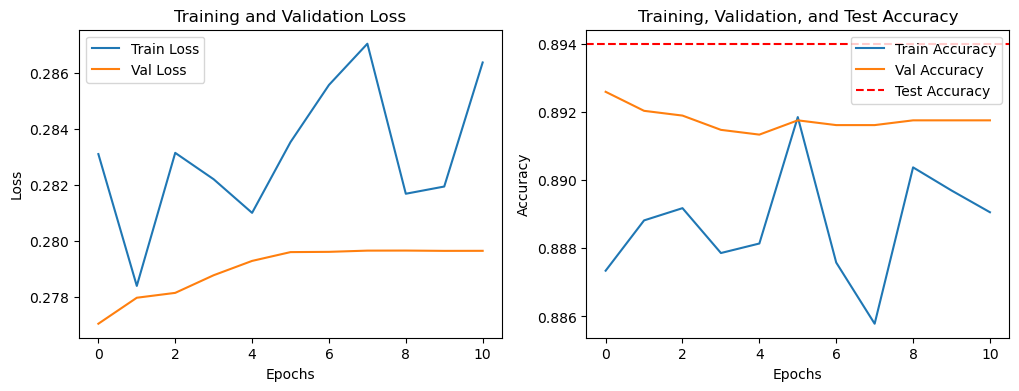

In [9]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,  # Start with a baseline number of epochs
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator),
    callbacks=callbacks
)

# Evaluate the model on the test data generator
evaluation = model.evaluate_generator(test_generator)

# Print the evaluation metrics for the test data
print("Test Loss:", evaluation[0])
print("Test Accuracy:", evaluation[1])

# Get predictions on the test data generator
test_predictions = model.predict_generator(test_generator)

# Convert predictions to class labels
test_predicted_classes = np.argmax(test_predictions, axis=1)

# Get true labels from the generator
test_true_classes = test_generator.classes

# Calculate accuracy for the test data
test_accuracy = np.mean(test_predicted_classes == test_true_classes)
print("Test Accuracy:", test_accuracy)

# Plot training, validation, and test curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.axhline(y=test_accuracy, color='r', linestyle='--', label='Test Accuracy')  # Test accuracy line
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training, Validation, and Test Accuracy')
plt.legend()

plt.show()
